# Task 2: Domain-Specific Fine-Tuning · AML Transaction-Alert Triage
**CDAZZDEV Senior MLE Assessment · Generative AI** · QLoRA (4-bit NF4) on `Qwen/Qwen2.5-1.5B-Instruct` · Colab T4

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_GITHUB_USERNAME/CDAZZDEV-MLE-YourName/blob/main/task2_genai/notebooks/Task2_AML_Triage_QLoRA.ipynb)

> **Runtime → Change runtime type → T4 GPU.** Add the Colab secrets `GROQ_API_KEY` (LLM judge) and `HF_TOKEN` (write access, for pushing the model).

## Problem statement
Bank transaction-monitoring systems raise thousands of alerts a day, and most of them are false positives. A level-1 analyst triages each alert: identify the typology, weigh the red flags against mitigating facts, and choose an action. General-purpose LLMs do this badly. They ignore the bank's label vocabulary, escalate everything, and, most dangerously, **invent amounts or counterparties**, which is unacceptable in a regulatory filing.

| | Specification |
|---|---|
| **Input** (user turn) | A rendered alert: rule triggered; customer profile (segment, business, tenure, KYC rating, declared turnover, residence); prior alerts; a table of 3–10 transactions (date, direction, type, amount, currency, counterparty, country); optional analyst context |
| **Output** (assistant turn) | JSON with `typology` (one of 11), `risk_level` (low/medium/high), `red_flags[]`, `mitigating_factors[]`, `recommended_action` (close_no_action / request_information / enhanced_due_diligence / escalate_sar), and a 2–3 sentence `rationale` |
| **Correct** | Valid JSON using only the allowed labels; typology and action match the investigator's gold decision; every cited fact (amount, date, counterparty, country) appears in the alert |
| **Partially correct** | Valid and grounded, but typology *or* action differs from gold (e.g. EDD instead of SAR) |
| **Incorrect / hallucinated** | Invalid JSON or labels; or any fact not present in the alert (a fabricated amount, total, document or counterparty) |

In [13]:
import os, sys, subprocess, json, gc, time
from pathlib import Path
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not Path("/content/repo").exists():
        subprocess.run(["git", "clone", "-q", "https://github.com/VHemantha/CDAZZDEV-MLE-Viraj-Hemantha.git", "/content/repo"], check=True)
    else:  # re-run after pushing fixes: always train the latest code
        subprocess.run(["git", "-C", "/content/repo", "pull", "-q"], check=True)
    os.chdir("/content/repo/task2_genai")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    from google.colab import userdata
    for k in ("GROQ_API_KEY", "HF_TOKEN", "HF_REPO_ID"):
        try: os.environ[k] = userdata.get(k)
        except Exception: pass
else:
    if Path.cwd().name == "notebooks": os.chdir(Path.cwd().parent)
    from dotenv import load_dotenv; load_dotenv(Path.cwd().parent / ".env", override=True)
sys.path.insert(0, str(Path.cwd()))
print({k: ("set" if os.getenv(k) else "missing") for k in ("GROQ_API_KEY", "HF_TOKEN")})
print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv"], capture_output=True, text=True).stdout)

{'GROQ_API_KEY': 'set', 'HF_TOKEN': 'set'}
name, memory.total [MiB]
Tesla T4, 15360 MiB



In [14]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display, Markdown
from aml_triage import config
from aml_triage.prompts import TEACHER_SYSTEM_PROMPT, STUDENT_SYSTEM_PROMPT
from aml_triage.schema import render_alert, render_triage
from aml_triage import dataset as D
pd.set_option("display.max_colwidth", 160)
config.OUTPUT_DIR.mkdir(exist_ok=True)

---
# 2A: Dataset engineering
## 2A.1 Teacher generation
* **Teacher:** `openai/gpt-oss-120b` via Groq (free tier), with OpenRouter and Qwen3.8-27B as fallbacks when a daily quota runs out. The teacher used is recorded per case. **The student, Qwen2.5-1.5B, is a different model.**
* **Diversity by construction:** each case comes from a *seed* that fixes the true typology (balanced, with 22% benign false positives), customer segment (15), jurisdictions (20), difficulty (`clear-cut` / `borderline` / `misleading-surface`) and transaction count.
* **Quality gate:** every case is validated with Pydantic and then with consistency checks: the label matches the seed, risk and action are coherent, and a **grounding check** rejects any figure the alert doesn't support (it handles totals, `1.07M`-style abbreviations and regulatory thresholds). Rejected cases are regenerated.

150 seeds were drawn; **131 cases passed the quality gate** within the free-tier token budget (112 from gpt-oss-120b, 19 from qwen3.8-27b). The dataset was generated once with `scripts/generate_dataset.py` and committed, so this notebook reuses it. Set `REGENERATE=True` to rebuild it (this costs about 150K teacher tokens). The full teacher system prompt is printed here and in the appendix.

In [15]:
REGENERATE = False
if REGENERATE or not config.RAW_PATH.exists():
    from aml_triage.generate import generate
    generate()
cases = D.load_cases()
print(f"{len(cases)} validated cases in {config.RAW_PATH.name}\n")
print("=== TEACHER SYSTEM PROMPT (full) ===\n" + TEACHER_SYSTEM_PROMPT)

131 validated cases in raw_cases.jsonl

=== TEACHER SYSTEM PROMPT (full) ===
You are a senior AML (anti-money-laundering) investigator at a global bank and an expert author
of training material for transaction-monitoring analysts. You write realistic, varied
transaction-monitoring ALERTS together with the GOLD-STANDARD triage decision a senior
investigator would reach.

For each scenario seed you receive, write ONE case that is faithful to the seed:
- The seed fixes the TRUE typology, customer segment, jurisdiction focus, difficulty, number of
  transactions and the share of benign activity. The gold triage MUST use the seed's typology.
- "clear-cut": the pattern is obvious. "borderline": genuine ambiguity, evidence partly supports
  an innocent explanation. "misleading-surface": the rule that fired suggests one thing but the
  full picture shows another (e.g. a structuring rule fires on a cash-heavy restaurant whose
  deposits match its declared turnover -> no_suspicious_activity; or 

In [16]:
ex = cases[0]
print("Seed:", ex.seed, "| teacher:", ex.teacher, "\n")
print("USER TURN (model input):\n" + render_alert(ex.alert))
print("\nASSISTANT TURN (target):\n" + render_triage(ex.triage))

Seed: {'seed_id': 0, 'true_typology': 'crypto_off_ramp', 'customer_segment': 'freelance software developer', 'jurisdiction_focus': ['Nigeria'], 'difficulty': 'clear-cut', 'n_transactions': 3, 'prior_alerts_hint': 2} | teacher: groq/gpt-oss-120b 

USER TURN (model input):
ALERT TM-26000 | Rule triggered: crypto_off_ramp_large_volume
Customer: freelance software developer - software developer (freelance); resident in Nigeria; account age 14 months; KYC risk rating medium; declared monthly turnover 4,500 USD.
Prior alerts in last 12 months: 2.
Transactions:
date       | dir | type | amount | counterparty (country)
2026-03-10 | in  | crypto_exchange_transfer | 12,000.00 USD | BitBridge Exchange (Cayman Islands)
2026-03-12 | in  | crypto_exchange_transfer | 8,500.50 USD | Nexo Crypto Ltd (Singapore)
2026-03-14 | in  | crypto_exchange_transfer | 9,000.75 USD | CoinX Global (Estonia)
Context: Customer supplied signed contracts and invoices for three software development projects with total va

## 2A.2 Diversity validation

Prompt length (words): {'mean': 154.15267175572518, 'std': 31.26089996957098, 'min': 100, 'p50': 148.0, 'max': 222} 
Answer length (words): {'mean': 117.12977099236642, 'min': 51, 'max': 218}
distinct-1 0.091 | distinct-2 0.297 | rules 122 | countries 44 | currencies 14
Near-duplicate analysis (5-gram shingle Jaccard over all pairs): {'pairs': 8515, 'mean_jaccard': 0.041, 'p95_jaccard': 0.071, 'max_jaccard': 0.117, 'pairs_above_0.5': 0}
Teachers: {'groq/gpt-oss-120b': 112, 'groq/qwen3.8-27b': 19}


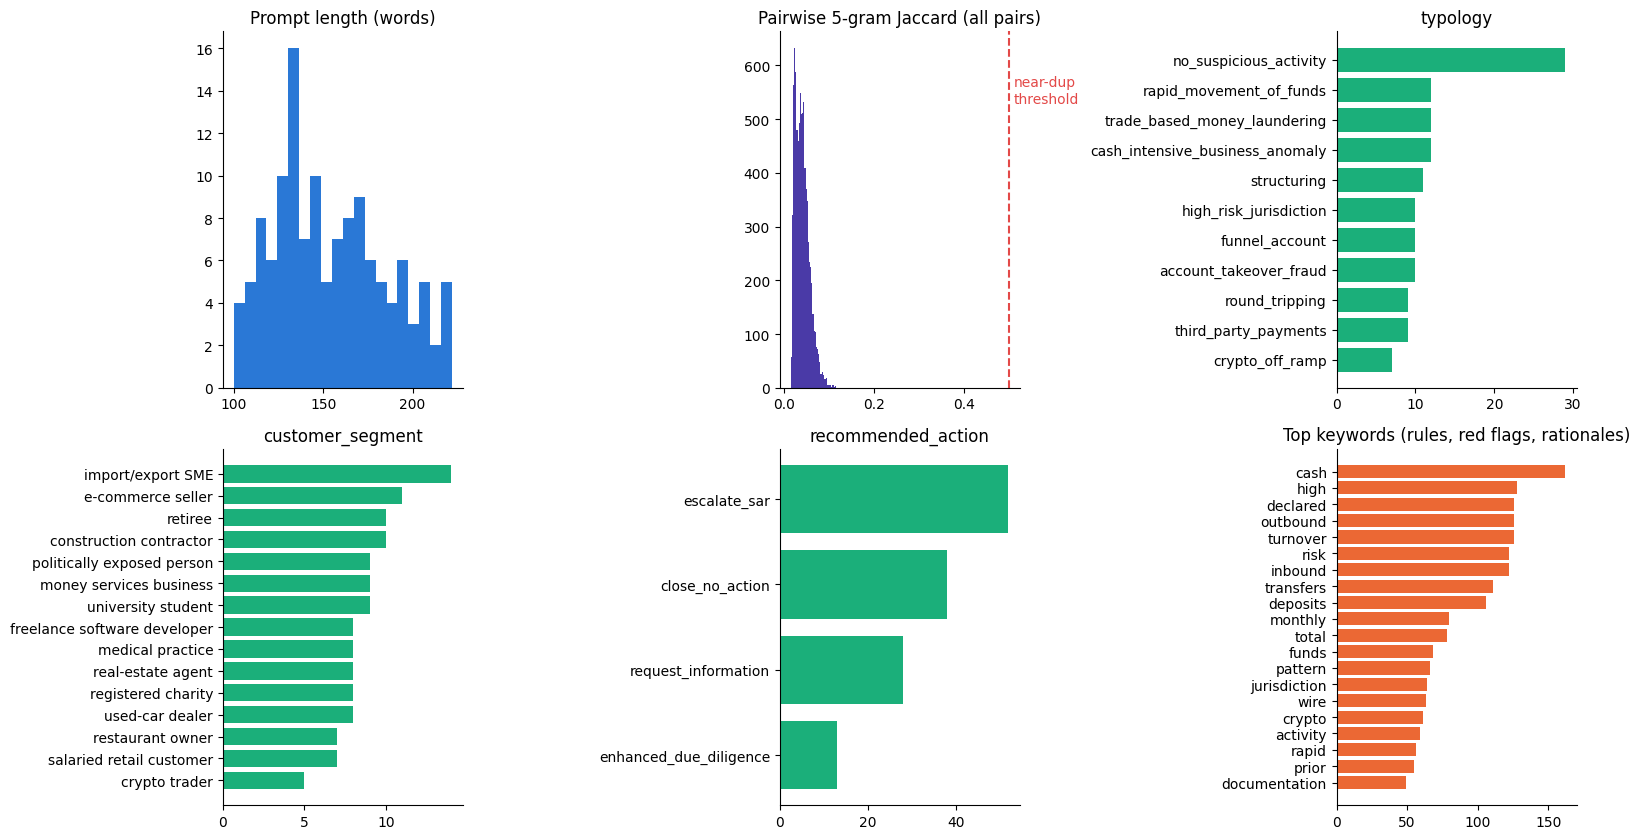

,clear-cut,borderline,misleading-surface
difficulty,50,56,25


,high,medium,low
risk_level,59,35,37


In [17]:
rep = D.diversity_report(cases)
print("Prompt length (words):", rep["prompt_words"], "\nAnswer length (words):", rep["answer_words"])
print(f"distinct-1 {rep['distinct_1']:.3f} | distinct-2 {rep['distinct_2']:.3f} | rules {rep['n_distinct_rules']} | "
      f"countries {rep['n_distinct_counterparty_countries']} | currencies {rep['n_distinct_currencies']}")
nd = {k: v for k, v in rep["near_duplicates"].items() if not k.startswith("_")}
print("Near-duplicate analysis (5-gram shingle Jaccard over all pairs):", {k: round(v, 3) if isinstance(v, float) else v for k, v in nd.items()})
print("Teachers:", dict(rep["teacher"]))

fig, ax = plt.subplots(2, 3, figsize=(16, 8.5))
ax[0, 0].hist(rep["_prompt_words"], bins=20, color="#2a78d6"); ax[0, 0].set_title("Prompt length (words)")
ax[0, 1].hist(rep["near_duplicates"]["_all"], bins=40, color="#4a3aa7"); ax[0, 1].set_title("Pairwise 5-gram Jaccard (all pairs)")
ax[0, 1].axvline(0.5, color="#e34948", ls="--"); ax[0, 1].text(0.51, ax[0, 1].get_ylim()[1] * 0.8, "near-dup\nthreshold", color="#e34948")
for a, key in [(ax[0, 2], "typology"), (ax[1, 0], "customer_segment"), (ax[1, 1], "recommended_action")]:
    s = pd.Series(rep[key]).sort_values(); a.barh(s.index, s.values, color="#1baf7a"); a.set_title(key)
kw = pd.Series(dict(rep["top_keywords"])).sort_values()
ax[1, 2].barh(kw.index[-20:], kw.values[-20:], color="#eb6834"); ax[1, 2].set_title("Top keywords (rules, red flags, rationales)")
for a in ax.flat: a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.savefig(config.OUTPUT_DIR / "dataset_diversity.png", dpi=110); plt.show()
display(pd.DataFrame({"difficulty": pd.Series(rep["difficulty"]), }).T, pd.DataFrame({"risk_level": pd.Series(rep["risk_level"])}).T)

## 2A.3 JSONL chat format and a stratified 80/10/10 split

In [18]:
splits = D.stratified_split(cases)
sizes = D.write_splits(splits)
print("Split sizes:", sizes, "| total", sum(sizes.values()))
display(pd.DataFrame({s: pd.Series([c.triage.typology for c in splits[s]]).value_counts() for s in splits}).fillna(0).astype(int))
train_rows, val_rows, test_rows = (D.read_split(s) for s in ("train", "val", "test"))
print("\nOne JSONL record (conversational prompt/completion format):")
print(json.dumps(train_rows[0], indent=1, ensure_ascii=False)[:1500], "...")

Split sizes: {'train': 105, 'val': 13, 'test': 13} | total 131


,train,val,test
account_takeover_fraud,8,1,1
cash_intensive_business_anomaly,9,1,2
crypto_off_ramp,6,1,0
funnel_account,8,1,1
high_risk_jurisdiction,7,2,1
no_suspicious_activity,23,3,3
rapid_movement_of_funds,10,1,1
round_tripping,8,0,1
structuring,8,2,1
third_party_payments,9,0,0



One JSONL record (conversational prompt/completion format):
{
 "case_id": "case-0119",
 "typology": "funnel_account",
 "recommended_action": "request_information",
 "prompt": [
  {
   "role": "system",
   "content": "You are an AML transaction-monitoring analyst. Triage the alert and respond with ONLY a JSON\nobject with keys: typology, risk_level, red_flags, mitigating_factors, recommended_action,\nrationale.\ntypology: one of ['structuring', 'rapid_movement_of_funds', 'funnel_account', 'trade_based_money_laundering', 'third_party_payments', 'high_risk_jurisdiction', 'cash_intensive_business_anomaly', 'account_takeover_fraud', 'crypto_off_ramp', 'round_tripping', 'no_suspicious_activity']\nrisk_level: one of ['low', 'medium', 'high']\nrecommended_action: one of ['close_no_action', 'request_information', 'enhanced_due_diligence', 'escalate_sar']\nred_flags and mitigating_factors are lists of short strings that must cite facts from the\nalert; never invent amounts, dates, names or coun

In [19]:
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained(config.BASE_MODEL)
rendered = tok.apply_chat_template(train_rows[0]["prompt"] + train_rows[0]["completion"], tokenize=False)
print("Rendered with the base model's own chat template (Qwen2.5 ChatML):\n")
print(rendered[:900], "\n...\n", rendered[-300:])
lens = [len(tok.apply_chat_template(r["prompt"] + r["completion"], tokenize=True)) for r in train_rows + val_rows + test_rows]
print(f"\nTokens per example: mean {np.mean(lens):.0f}, max {max(lens)} -> max_seq_length=1024 truncates nothing: {max(lens) < 1024}")

Rendered with the base model's own chat template (Qwen2.5 ChatML):

<|im_start|>system
You are an AML transaction-monitoring analyst. Triage the alert and respond with ONLY a JSON
object with keys: typology, risk_level, red_flags, mitigating_factors, recommended_action,
rationale.
typology: one of ['structuring', 'rapid_movement_of_funds', 'funnel_account', 'trade_based_money_laundering', 'third_party_payments', 'high_risk_jurisdiction', 'cash_intensive_business_anomaly', 'account_takeover_fraud', 'crypto_off_ramp', 'round_tripping', 'no_suspicious_activity']
risk_level: one of ['low', 'medium', 'high']
recommended_action: one of ['close_no_action', 'request_information', 'enhanced_due_diligence', 'escalate_sar']
red_flags and mitigating_factors are lists of short strings that must cite facts from the
alert; never invent amounts, dates, names or countries. rationale: 2-3 sentences.<|im_end|>
<|im_start|>user
ALERT TM-26119 | Rule triggered: unusual_cash_ 
...
 "request_information",
 "

---
# 2B: QLoRA fine-tuning
## 2B.1 Every hyperparameter and why
This table is generated from `aml_triage/train.py::HYPERPARAMETERS`, the same dict the configs are built from, so the documentation can't drift from what was trained.

In [20]:
from aml_triage.train import hyperparameter_table, HP
display(pd.DataFrame(hyperparameter_table()))

,hyperparameter,value,justification
0,base_model,Qwen/Qwen2.5-1.5B-Instruct,"Qwen2.5-1.5B-Instruct: strong instruction/JSON following for its size, a native ChatML template with a system role, and Apache-2.0. It trains comfortably on..."
1,load_in_4bit / quant_type,nf4,"NF4 is the information-theoretically optimal 4-bit type for normally distributed weights (QLoRA paper). The base weights drop to about 1.1 GB, which leaves ..."
2,bnb_4bit_use_double_quant,True,"Also quantises the quantisation constants, saving about 0.4 bits/param at no measurable quality cost."
3,bnb_4bit_compute_dtype,float16,"The T4 (Turing) has no bfloat16 support, so fp16 compute is the fastest supported option."
4,lora_r,16,"The task is mostly format, label vocabulary and grounding discipline, not new world knowledge. With 105 training examples, r=16 gives enough capacity (~18M ..."
5,lora_alpha,32,"alpha/r = 2, the common scaling that keeps the adapter update magnitude stable if r is changed and works well with lr=2e-4."
6,lora_dropout,0.05,Light regularisation for a small dataset; higher values slowed convergence in QLoRA ablations.
7,target_modules,"[q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj]","All linear layers. The QLoRA paper shows attention-only LoRA underperforms, and adapting the MLP layers is needed to match full fine-tuning quality."
8,learning_rate,0.0002,"The QLoRA reference LR for models of this size. LoRA adapters start at zero, so they tolerate a higher LR than full fine-tuning."
9,lr_scheduler_type,cosine,"Cosine decay to ~0 makes the final epoch's updates small, which stabilises the end-of-training validation loss on a tiny dataset."


## 2B.2 Train (4-bit NF4 base + LoRA adapters), logging train and val loss
**OOM handling:** if the T4 runs out of memory, the cell records the error, halves the micro-batch, doubles gradient accumulation (so the effective batch stays at 8), and retries. The log below shows what happened in this run.

In [21]:
import torch
from aml_triage import train as TR
from peft import PeftModel
oom_log = []
attempt_cfg = [(HP["per_device_train_batch_size"], HP["gradient_accumulation_steps"]), (1, 8)]
for bs, ga in attempt_cfg:
    TR.HP["per_device_train_batch_size"], TR.HP["gradient_accumulation_steps"] = bs, ga
    try:
        t0 = time.time()
        trainer = TR.train(train_rows, val_rows, output_dir="outputs/qlora_run")
        print(f"Training finished in {(time.time() - t0) / 60:.1f} min with batch {bs} x accum {ga}")
        break
    except torch.cuda.OutOfMemoryError as e:
        oom_log.append({"batch_size": bs, "grad_accum": ga, "error": str(e)[:200]})
        print(f"OOM with batch {bs} -> retrying with smaller micro-batch (effective batch unchanged)")
        gc.collect(); torch.cuda.empty_cache()
print("OOM events:", oom_log or "none")
trainer.model.print_trainable_parameters()
print("Quantisation:", trainer.model.base_model.model.config.quantization_config)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Tokenizing train dataset:   0%|          | 0/105 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/105 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/105 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/105 [00:00<?, ? examples/s]

...

Truncating eval dataset:   0%|          | 0/13 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/13 [00:00<?, ? examples/s]

trainable params by dtype before cast: {'torch.bfloat16': 18464768} -> all float32


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,1.160963,1.120743,1.184679,82409.000000,0.728820
2,0.974278,1.043074,0.983249,164818.000000,0.737567
3,0.851947,1.036816,0.948718,247227.000000,0.738871


Training finished in 6.1 min with batch 2 x accum 4
OOM events: none
trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820
Quantisation: BitsAndBytesConfig {
  "_load_in_4bit": true,
  "_load_in_8bit": false,
  "bnb_4bit_compute_dtype": "float16",
  "bnb_4bit_quant_storage": "uint8",
  "bnb_4bit_quant_type": "nf4",
  "bnb_4bit_use_double_quant": true,
  "llm_int8_enable_fp32_cpu_offload": false,
  "llm_int8_has_fp16_weight": false,
  "llm_int8_skip_modules": null,
  "llm_int8_threshold": 6.0,
  "load_in_4bit": true,
  "load_in_8bit": false,
  "quant_method": "bitsandbytes"
}



,epoch,train_loss,val_loss
0,1,1.2879,1.1207
1,2,1.0348,1.0431
2,3,0.8798,1.0368


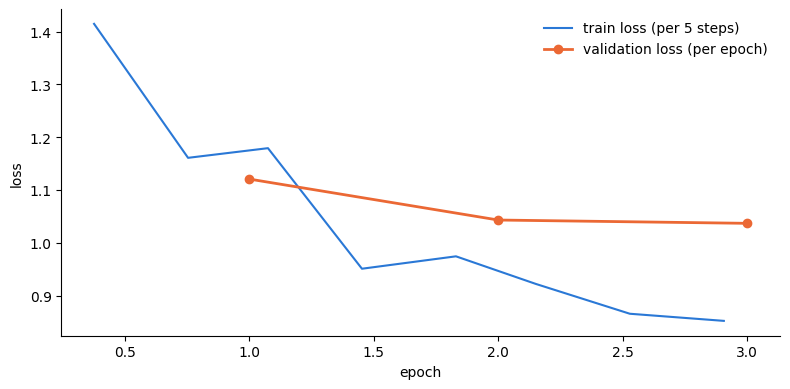

Validation loss strictly decreasing across epochs: True


In [22]:
ep = pd.DataFrame(TR.epoch_losses(trainer.state.log_history))
display(ep.round(4))
steps = pd.DataFrame([r for r in trainer.state.log_history if "loss" in r])
fig, a = plt.subplots(figsize=(8, 4))
a.plot(steps["epoch"], steps["loss"], color="#2a78d6", lw=1.5, label="train loss (per 5 steps)")
a.plot(ep["epoch"], ep["val_loss"], "o-", color="#eb6834", lw=2, label="validation loss (per epoch)")
a.set_xlabel("epoch"); a.set_ylabel("loss"); a.legend(frameon=False); a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.savefig(config.OUTPUT_DIR / "loss_curves.png", dpi=110); plt.show()
dec = all(b < a_ for a_, b in zip(ep["val_loss"], ep["val_loss"][1:]))
print("Validation loss strictly decreasing across epochs:", dec)
ep.to_csv(config.OUTPUT_DIR / "epoch_losses.csv", index=False)

## 2B.3 Merge the adapters with `merge_and_unload()`, save, and push to the Hugging Face Hub

In [23]:
!pip uninstall -y torchao
!pip install -U "torchao>=0.16.0"
ADAPTER_DIR, MERGED_DIR = "outputs/adapter", "outputs/merged"
trainer.save_model(ADAPTER_DIR)
del trainer; gc.collect(); torch.cuda.empty_cache()
ft_model, ft_tok = TR.merge_and_save(ADAPTER_DIR, MERGED_DIR)
print("Merged model saved:", sorted(os.listdir(MERGED_DIR)))
repo_id = os.getenv("HF_REPO_ID") or config.HF_REPO_ID
if os.getenv("HF_TOKEN") and "YOUR_HF_USERNAME" not in repo_id:
    ft_model.push_to_hub(repo_id, token=os.environ["HF_TOKEN"], private=False)
    ft_tok.push_to_hub(repo_id, token=os.environ["HF_TOKEN"])
    print("Pushed: https://huggingface.co/" + repo_id)
else:
    print("Set HF_TOKEN and HF_REPO_ID secrets to push; model kept at", MERGED_DIR)

Found existing installation: torchao 0.18.0
Uninstalling torchao-0.18.0:
  Successfully uninstalled torchao-0.18.0
  Using cached torchao-0.18.0-cp310-abi3-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (21 kB)
Using cached torchao-0.18.0-cp310-abi3-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (3.4 MB)


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Merged model saved: ['chat_template.jinja', 'config.json', 'generation_config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json']


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpq3lgnyys/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

Validating                    :           |   0%            

Pushed: https://huggingface.co/Vhemantha/qwen2.5-1.5b-aml-alert-triage


---
# 2C: Evaluation against the base model (same system prompt, same held-out test set)
Both models run in fp16 with greedy decoding and an identical system prompt. The only difference is the fine-tuning.

In [24]:
from aml_triage import evaluate as E
from transformers import AutoModelForCausalLM
ft_model.eval()
ft_preds = E.run_inference(ft_model, ft_tok, test_rows, "fine-tuned")
base_model = AutoModelForCausalLM.from_pretrained(config.BASE_MODEL, device_map="auto", **TR._dtype_kw(torch.float16)).eval()
base_preds = E.run_inference(base_model, ft_tok, test_rows, "base")
del base_model; gc.collect(); torch.cuda.empty_cache()
golds = [r["completion"][0]["content"] for r in test_rows]
json.dump({"base": base_preds, "fine_tuned": ft_preds}, open(config.OUTPUT_DIR / "test_predictions.json", "w"), indent=1)

  [fine-tuned] 1/13 case-0081 ppl=1.516 tokens=145
  [fine-tuned] 2/13 case-0128 ppl=1.504 tokens=143
  [fine-tuned] 3/13 case-0103 ppl=1.449 tokens=133
  [fine-tuned] 4/13 case-0086 ppl=1.787 tokens=165
  [fine-tuned] 5/13 case-0089 ppl=1.642 tokens=228
  [fine-tuned] 6/13 case-0108 ppl=1.374 tokens=85
  [fine-tuned] 7/13 case-0025 ppl=1.412 tokens=99
  [fine-tuned] 8/13 case-0024 ppl=1.517 tokens=161
  [fine-tuned] 9/13 case-0101 ppl=1.659 tokens=113
  [fine-tuned] 10/13 case-0009 ppl=1.501 tokens=144
  [fine-tuned] 11/13 case-0055 ppl=1.732 tokens=173
  [fine-tuned] 12/13 case-0014 ppl=1.672 tokens=131
  [fine-tuned] 13/13 case-0126 ppl=1.391 tokens=99


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

  [base] 1/13 case-0081 ppl=1.316 tokens=103
  [base] 2/13 case-0128 ppl=1.286 tokens=105
  [base] 3/13 case-0103 ppl=1.537 tokens=158
  [base] 4/13 case-0086 ppl=1.592 tokens=158
  [base] 5/13 case-0089 ppl=1.385 tokens=129
  [base] 6/13 case-0108 ppl=1.408 tokens=138
  [base] 7/13 case-0025 ppl=1.548 tokens=155
  [base] 8/13 case-0024 ppl=1.336 tokens=109
  [base] 9/13 case-0101 ppl=1.337 tokens=115
  [base] 10/13 case-0009 ppl=1.407 tokens=100
  [base] 11/13 case-0055 ppl=1.599 tokens=120
  [base] 12/13 case-0014 ppl=1.405 tokens=138
  [base] 13/13 case-0126 ppl=1.529 tokens=128


## 2C.1 ROUGE-L and task-level accuracy

In [25]:
rows = []
for name, preds in [("Base (system prompt only)", base_preds), ("Fine-tuned (QLoRA)", ft_preds)]:
    texts = [p["text"] for p in preds]
    rl = E.rouge_l(texts, golds)
    fm = E.field_metrics(texts, golds)
    rows.append({"model": name, "ROUGE-L (mean)": np.mean(rl), "ROUGE-L (median)": np.median(rl), **fm})
results = pd.DataFrame(rows).set_index("model")
display(results.round(3))
results.to_csv(config.OUTPUT_DIR / "metrics_rouge_fields.csv")

,ROUGE-L (mean),ROUGE-L (median),valid_json_schema,typology_acc,action_acc,risk_acc
model,,,,,,
Base (system prompt only),0.259,0.244,0.385,0.154,0.154,0.231
Fine-tuned (QLoRA),0.347,0.337,0.923,0.615,0.615,0.538


## 2C.2 Additional metrics: BERTScore F1 and an LLM-as-judge with a structured JSON rubric

In [26]:
from aml_triage.schema import Case
test_cases = {c.case_id: c for c in cases}
judge_rows = []
for name, preds in [("base", base_preds), ("fine-tuned", ft_preds)]:
    f1 = E.bertscore_f1([p["text"] for p in preds], golds)
    for p, g, r, f in zip(preds, golds, test_rows, f1):
        js = E.judge(r["prompt"][1]["content"], g, p["text"])
        judge_rows.append({"model": name, "case_id": p["case_id"], "bertscore_f1": f,
                           **(js.model_dump() if js else {})})
J = pd.DataFrame(judge_rows)
summary = J.groupby("model")[["bertscore_f1", "decision_accuracy", "grounding", "reasoning_quality",
                              "format_compliance", "hallucination"]].mean().round(3)
display(summary)
print("Example judge output (structured JSON):"); print(J.iloc[-1][["decision_accuracy", "grounding", "reasoning_quality", "format_compliance", "hallucination", "comment"]].to_dict())
J.to_csv(config.OUTPUT_DIR / "judge_scores.csv", index=False)

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,bertscore_f1,decision_accuracy,grounding,reasoning_quality,format_compliance,hallucination
model,,,,,,
base,0.342,1.692,3.538,2.000,5.0,0.385
fine-tuned,0.476,3.462,2.385,2.308,5.0,0.692


Example judge output (structured JSON):
{'decision_accuracy': 5, 'grounding': 4, 'reasoning_quality': 4, 'format_compliance': 5, 'hallucination': False, 'comment': 'Good overall but omitted the identified red‑flag, reducing grounding and reasoning scores slightly.'}


## 2C.3 Hallucination rate: manual review of fine-tuned outputs
All 13 held-out test outputs (the brief asks for at least 10) are listed below with an **automatic pre-label** to speed up review. The pre-label combines invented-figure detection, the judge's hallucination flag, and label agreement. **The final labels in `reviewer_label` are assigned by a human reviewer**, who reads each alert next to the output; the pre-label is only a suggestion. The sheet is saved to `outputs/manual_review.csv`.

In [27]:
review = []
jl = J[J.model == "fine-tuned"].set_index("case_id")
for p, g, r in zip(ft_preds, golds, test_rows):
    case = test_cases[p["case_id"]]
    js = jl.loc[p["case_id"]] if p["case_id"] in jl.index else None
    judge_obj = E.JudgeScore(**js[["decision_accuracy", "grounding", "reasoning_quality", "format_compliance", "hallucination", "comment"]].to_dict()) if js is not None and not js.isna().any() else None
    label, why = E.suggest_label(p["text"], g, case.alert, judge_obj)
    pt, gt = E.parse_triage(p["text"]), E.parse_triage(g)
    review.append({"case_id": p["case_id"], "gold": f"{gt.typology} / {gt.recommended_action}",
                   "prediction": f"{pt.typology} / {pt.recommended_action}" if pt else "INVALID",
                   "suggested_label": label, "evidence": why, "reviewer_label": ""})
R = pd.DataFrame(review)
REVIEW_PATH = config.OUTPUT_DIR / "manual_review.csv"
if REVIEW_PATH.exists():          # keep the human's labels across re-runs
    prev = pd.read_csv(REVIEW_PATH).set_index("case_id")["reviewer_label"].fillna("")
    R["reviewer_label"] = R["case_id"].map(prev).fillna("")
R.to_csv(REVIEW_PATH, index=False)
display(R)

,case_id,gold,prediction,suggested_label,evidence,reviewer_label
0,case-0081,high_risk_jurisdiction / escalate_sar,high_risk_jurisdiction / escalate_sar,hallucinated,"ungrounded figures ['43,000.00']",
1,case-0128,structuring / escalate_sar,cash_intensive_business_anomaly / escalate_sar,hallucinated,"ungrounded figures ['49,600']",
2,case-0103,cash_intensive_business_anomaly / escalate_sar,cash_intensive_business_anomaly / escalate_sar,hallucinated,"ungrounded figures ['121,500.00']",
3,case-0086,account_takeover_fraud / escalate_sar,INVALID,hallucinated,output is not valid triage JSON,
4,case-0089,rapid_movement_of_funds / request_information,rapid_movement_of_funds / request_information,hallucinated,"ungrounded figures ['16,100.00']",
5,case-0108,no_suspicious_activity / close_no_action,no_suspicious_activity / close_no_action,correct,typology and action match gold; no ungrounded facts detected,
6,case-0025,no_suspicious_activity / close_no_action,no_suspicious_activity / close_no_action,hallucinated,"judge: Reasoning adds unsupported claim about jurisdiction safety, but otherwise matches gold.",
7,case-0024,funnel_account / escalate_sar,third_party_payments / close_no_action,partially_correct,typology third_party_payments vs funnel_account; action close_no_action vs escalate_sar,
8,case-0101,trade_based_money_laundering / request_information,no_suspicious_activity / close_no_action,hallucinated,"judge: Analyst missed key red flags and recommended closing, contradicting gold triage and adds unsupported assertions.",
9,case-0009,cash_intensive_business_anomaly / request_information,cash_intensive_business_anomaly / escalate_sar,hallucinated,"judge: Analyst misstates deposit count/total and recommends escalation contrary to gold, showing poor grounding and reasoning.",


In [28]:
labels = [h if h in E.REVIEW_LABELS else s for h, s in zip(R["reviewer_label"], R["suggested_label"])]
n_human = sum(h in E.REVIEW_LABELS for h in R["reviewer_label"])
print(f"Reviewed responses: {len(labels)} ({n_human} human-confirmed labels, {len(labels) - n_human} pre-labels pending review)")
print(pd.Series(labels).value_counts().to_string())
print(f"\nHallucination rate (fine-tuned): {E.hallucination_rate(labels):.1f}%")

Reviewed responses: 13 (0 human-confirmed labels, 13 pre-labels pending review)
hallucinated         9
correct              2
partially_correct    2

Hallucination rate (fine-tuned): 69.2%


## 2C.4 Evidence for the qualitative analysis

In [29]:
bp = {p["case_id"]: E.parse_triage(p["text"]) for p in base_preds}
fp = {p["case_id"]: E.parse_triage(p["text"]) for p in ft_preds}
gp = {r["case_id"]: E.parse_triage(r["completion"][0]["content"]) for r in test_rows}
def lab(t): return f"{t.typology} / {t.recommended_action}" if t else "INVALID JSON"
cmp = pd.DataFrame([{"case_id": k, "difficulty": test_cases[k].seed["difficulty"], "gold": lab(gp[k]),
                     "base": lab(bp[k]), "fine-tuned": lab(fp[k]),
                     "base_ok": bool(bp[k] and bp[k].recommended_action == gp[k].recommended_action),
                     "ft_ok": bool(fp[k] and fp[k].recommended_action == gp[k].recommended_action)} for k in gp])
display(cmp)
fixed = cmp[(~cmp.base_ok) & cmp.ft_ok]
if len(fixed):
    k = fixed.iloc[0]["case_id"]
    print(f"\nExample fixed by fine-tuning ({k}):\n--- BASE ---")
    print(next(p["text"] for p in base_preds if p["case_id"] == k)[:900])
    print("--- FINE-TUNED ---"); print(next(p["text"] for p in ft_preds if p["case_id"] == k)[:900])

,case_id,difficulty,gold,base,fine-tuned,base_ok,ft_ok
0,case-0081,clear-cut,high_risk_jurisdiction / escalate_sar,INVALID JSON,high_risk_jurisdiction / escalate_sar,False,True
1,case-0128,clear-cut,structuring / escalate_sar,cash_intensive_business_anomaly / request_information,cash_intensive_business_anomaly / escalate_sar,False,True
2,case-0103,clear-cut,cash_intensive_business_anomaly / escalate_sar,INVALID JSON,cash_intensive_business_anomaly / escalate_sar,False,True
3,case-0086,clear-cut,account_takeover_fraud / escalate_sar,INVALID JSON,INVALID JSON,False,False
4,case-0089,borderline,rapid_movement_of_funds / request_information,rapid_movement_of_funds / request_information,rapid_movement_of_funds / request_information,True,True
5,case-0108,borderline,no_suspicious_activity / close_no_action,INVALID JSON,no_suspicious_activity / close_no_action,False,True
6,case-0025,clear-cut,no_suspicious_activity / close_no_action,INVALID JSON,no_suspicious_activity / close_no_action,False,True
7,case-0024,clear-cut,funnel_account / escalate_sar,third_party_payments / request_information,third_party_payments / close_no_action,False,False
8,case-0101,borderline,trade_based_money_laundering / request_information,cash_intensive_business_anomaly / request_information,no_suspicious_activity / close_no_action,True,False
9,case-0009,borderline,cash_intensive_business_anomaly / request_information,INVALID JSON,cash_intensive_business_anomaly / escalate_sar,False,False



Example fixed by fine-tuning (case-0081):
--- BASE ---
```json
{
  "typology": "high_risk_country_inbound",
  "risk_level": "high",
  "red_flags": [
    "Customer's beneficial owner is a German citizen.",
    "Business is registered in Berlin."
  ],
  "mitigating_factors": [],
  "recommended_action": "request_information",
  "rationale": "The customer has a German beneficial owner and a business registered in Berlin, which indicates potential money laundering risks associated with transactions to India."
}
```
--- FINE-TUNED ---
{
 "typology": "high_risk_jurisdiction",
 "risk_level": "high",
 "red_flags": [
  "Inbound funds from India totalling 43,000.00 EUR represent 86% of the customer's declared monthly turnover.",
  "All counterparties are Indian entities listed on sanctions lists."
 ],
 "mitigating_factors": [],
 "recommended_action": "escalate_sar",
 "rationale": "The large volume of inbound funds from sanctioned jurisdictions (India) exceeds the customer’s declared turnover by 

### Qualitative analysis
**Where fine-tuning improved behaviour.** *[Write after the run, using the tables above: cite specific case_ids. For example, base-model outputs that broke the label vocabulary or the JSON contract and were fixed; cases where the base model escalated benign `misleading-surface` alerts that the fine-tuned model correctly closed; changes in the judge's grounding score.]*

**Remaining failure modes and next steps.** *[Write after the run: which typologies or difficulties still fail (see `cmp`), any ungrounded figures, and what would address them. For example: more `borderline` and `misleading-surface` examples for the confused typology pairs, DPO on (grounded, hallucinated) answer pairs, or larger r / more epochs if validation loss was still falling.]*

---
# Bonus: RAG fallback layer (perplexity-gated, ChromaDB)
* **Confidence signal:** the perplexity of the generated answer, `exp(-mean token log-prob)`. A low-confidence answer has high perplexity.
* **Threshold:** the 75th percentile of perplexity on the **validation** set, so it's calibrated without touching the test set.
* **Knowledge base (ChromaDB):** the 11-entry AML typology handbook (`data/knowledge_base/`) plus the **training** cases with their gold decisions. Validation and test cases are excluded, so nothing leaks.
* **Fallback:** if perplexity is above the threshold, retrieve the top-2 handbook entries and top-2 similar cases, then re-query the model.

In [30]:
from aml_triage import rag
col = rag.build_store(train_rows)
val_ppl = [E.generate(ft_model, ft_tok, r["prompt"])["perplexity"] for r in val_rows]
thr = rag.calibrate_threshold(val_ppl)
print(f"Validation perplexity: median {np.median(val_ppl):.3f}, p75 threshold {thr:.3f}; KB size {col.count()} documents")
rag_out = [rag.answer_with_fallback(ft_model, ft_tok, col, r, thr) for r in test_rows]
rag_tab = pd.DataFrame([{"case_id": o["case_id"], "ppl": round(o["first"]["perplexity"], 3), "used_rag": o["used_rag"],
                         "gold": lab(gp[o["case_id"]]), "before": lab(E.parse_triage(o["first"]["text"])),
                         "after": lab(E.parse_triage(o["final"]["text"]))} for o in rag_out])
display(rag_tab)
acc = lambda col_: np.mean([E.parse_triage(o[col_]["text"]) is not None and E.parse_triage(o[col_]["text"]).recommended_action == gp[o["case_id"]].recommended_action for o in rag_out])
print(f"Action accuracy without RAG {acc('first'):.2f} -> with perplexity-gated RAG {acc('final'):.2f}")

/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:02<00:00, 29.8MiB/s]


Validation perplexity: median 1.558, p75 threshold 1.640; KB size 116 documents


,case_id,ppl,used_rag,gold,before,after
0,case-0081,1.516,False,high_risk_jurisdiction / escalate_sar,high_risk_jurisdiction / escalate_sar,high_risk_jurisdiction / escalate_sar
1,case-0128,1.504,False,structuring / escalate_sar,cash_intensive_business_anomaly / escalate_sar,cash_intensive_business_anomaly / escalate_sar
2,case-0103,1.449,False,cash_intensive_business_anomaly / escalate_sar,cash_intensive_business_anomaly / escalate_sar,cash_intensive_business_anomaly / escalate_sar
3,case-0086,1.787,True,account_takeover_fraud / escalate_sar,INVALID JSON,cash_intensive_business_anomaly / request_information
4,case-0089,1.642,True,rapid_movement_of_funds / request_information,rapid_movement_of_funds / request_information,rapid_movement_of_funds / request_information
5,case-0108,1.374,False,no_suspicious_activity / close_no_action,no_suspicious_activity / close_no_action,no_suspicious_activity / close_no_action
6,case-0025,1.412,False,no_suspicious_activity / close_no_action,no_suspicious_activity / close_no_action,no_suspicious_activity / close_no_action
7,case-0024,1.517,False,funnel_account / escalate_sar,third_party_payments / close_no_action,third_party_payments / close_no_action
8,case-0101,1.659,True,trade_based_money_laundering / request_information,no_suspicious_activity / close_no_action,cash_intensive_business_anomaly / escalate_sar
9,case-0009,1.501,False,cash_intensive_business_anomaly / request_information,cash_intensive_business_anomaly / escalate_sar,cash_intensive_business_anomaly / escalate_sar


Action accuracy without RAG 0.62 -> with perplexity-gated RAG 0.54


In [31]:
used = [o for o in rag_out if o["used_rag"]]
if used:
    o = max(used, key=lambda x: x["first"]["perplexity"])
    print(f"BEFORE/AFTER example ({o['case_id']}, perplexity {o['first']['perplexity']:.3f} > {thr:.3f})\n")
    print("GOLD:", lab(gp[o["case_id"]]))
    print("\n--- BEFORE (no retrieval) ---\n" + o["first"]["text"][:900])
    print("\n--- RETRIEVED CONTEXT (truncated) ---\n" + o["context"][:700])
    print("\n--- AFTER (with retrieval) ---\n" + o["final"]["text"][:900])
else:
    print("No test answer exceeded the confidence threshold.")

BEFORE/AFTER example (case-0086, perplexity 1.787 > 1.640)

GOLD: account_takeover_fraud / escalate_sar

--- BEFORE (no retrieval) ---
{
 "typology": "unusual_geographic_activity",
 "risk_level": "high",
 "red_flags": [
  "Outflows totaling 7,980.00 SGD within four days to three UAE ATMs, each over 1,000.00 SGD.",
  "No apparent business justification for such large sums being transferred internationally.",
  "Account manager was unable to reach the billing department despite multiple attempts."
 ],
 "mitigating_factors": [],
 "recommended_action": "escalate_sar",
 "rationale": "The rapid movement of funds to unrelated UAE ATMs without any legitimate business purpose is highly suspicious activity indicative of offshore layering. The lack of communication with the client’s staff further raises suspicion. Given the high volume and destination country, SAR filing is required."
}

--- RETRIEVED CONTEXT (truncated) ---
[handbook: structuring]
# structuring

**Definition.** Breaking cash dep

---
## Appendix: prompts used

In [32]:
print("=== TEACHER (data generation) ===\n" + TEACHER_SYSTEM_PROMPT)
print("\n=== STUDENT (base and fine-tuned, identical) ===\n" + STUDENT_SYSTEM_PROMPT)
from aml_triage.prompts import JUDGE_SYSTEM_PROMPT; print("\n=== LLM JUDGE ===\n" + JUDGE_SYSTEM_PROMPT)

=== TEACHER (data generation) ===
You are a senior AML (anti-money-laundering) investigator at a global bank and an expert author
of training material for transaction-monitoring analysts. You write realistic, varied
transaction-monitoring ALERTS together with the GOLD-STANDARD triage decision a senior
investigator would reach.

For each scenario seed you receive, write ONE case that is faithful to the seed:
- The seed fixes the TRUE typology, customer segment, jurisdiction focus, difficulty, number of
  transactions and the share of benign activity. The gold triage MUST use the seed's typology.
- "clear-cut": the pattern is obvious. "borderline": genuine ambiguity, evidence partly supports
  an innocent explanation. "misleading-surface": the rule that fired suggests one thing but the
  full picture shows another (e.g. a structuring rule fires on a cash-heavy restaurant whose
  deposits match its declared turnover -> no_suspicious_activity; or a benign-looking salary
  account that is a